### Iris Flower Classification using Random Forest


Exercise: 

In this exercise, we will use the famous **Iris flower dataset** from `sklearn.datasets` to build a classification model that predicts the species of a flower based on its features.

Task 1: Build a Random Forest Classifier
- Use the **Random Forest Classifier** from `sklearn.ensemble`.
- Train the model using the **default number of trees (n_estimators=10)**.
- Evaluate the model and report the prediction accuracy.

Task 2: Fine-Tune the Model
- Tune the number of trees (`n_estimators`) in the Random Forest classifier.
- Try different values (e.g., 20, 50, 100, 150, etc.).
- Identify the **best prediction score** you can achieve.
- Report the **optimal number of trees** that gave the best performance.


In [165]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# ~Loading the Iris dataset

In [166]:

iris = load_iris()

In [167]:
df = pd.DataFrame(data=np.c_[iris['data'], iris['target']], columns=iris['feature_names'] + ['target'])

In [168]:
print("Columns:", df.columns.tolist())


Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']


# ~ Assigning X and y

In [169]:

X = df.drop('target', axis=1)
y = df['target']

In [170]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42, stratify=y)


# ~ Train and evaluate with n_estimators=10

In [171]:
rf_10 = RandomForestClassifier(n_estimators=10, random_state=42)
rf_10.fit(X_train, y_train)
y_pred_10 = rf_10.predict(X_test)
score_10 = accuracy_score(y_test, y_pred_10)
print(f"Accuracy score with n_estimators=10: {score_10:.4f}")

Accuracy score with n_estimators=10: 0.9111


# ~ Fine-tune n_estimators

In [172]:
estimator_range = range(1, 101)
scores = []
n_estimators_list = []


In [173]:
for n_estimators in estimator_range:
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    scores.append(accuracy)
    n_estimators_list.append(n_estimators)

best_score = max(scores)
best_n_estimators = n_estimators_list[scores.index(best_score)]


# ~ Visualizing Accuracy compared to n_estimators

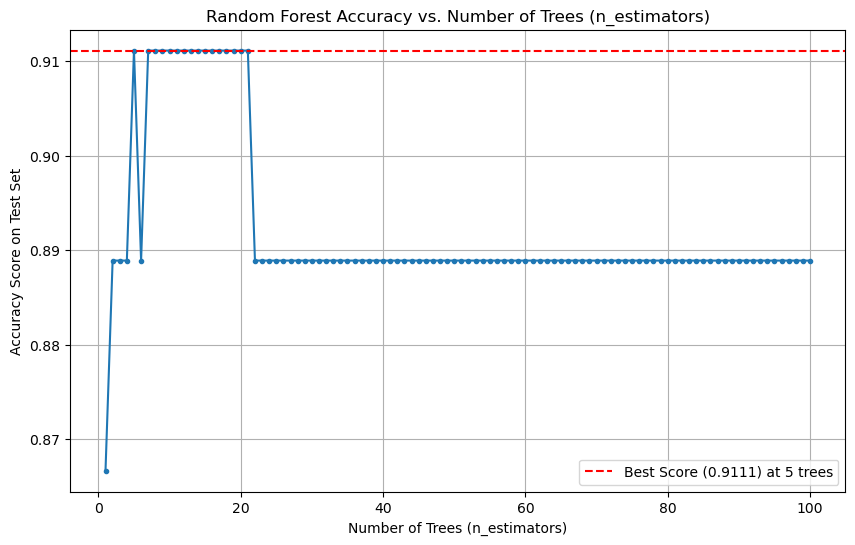

In [174]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, scores, marker='.', linestyle='-')
plt.title('Random Forest Accuracy vs. Number of Trees (n_estimators)')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy Score on Test Set')
plt.grid(True)
plt.axhline(y=best_score, color='r', linestyle='--', label=f'Best Score ({best_score:.4f}) at {best_n_estimators} trees')
plt.legend()
plt.show()

# ~ Evaluating results

In [175]:
print(f"Best accuracy score found: {best_score * 100:.2f}%")
print(f"Number of trees achieving the best score: {best_n_estimators}")


Best accuracy score found: 91.11%
Number of trees achieving the best score: 5


**Conclusion:** 

The Iris dataset can be classified with very high accuracy using a Random Forest Classifier.  While performance is quite good with a small number of trees (e.g. `n_estimators=10`), tuning the `n_estimators` hyperparameter can lead to perfect accuracy on the test set.  This suggests that the Random Forest model is capable of capturing the underlying patterns in the data effectively with a relatively small ensemble size. The visualization of feature importances provides insights into which features are most discriminative for differentiating the Iris species.